# Credit Valuation Adjustment (CVA)
QRE-53

CVA is the market value of counterparty credit risk: the expected loss from a counterparty defaulting while the derivative has positive value to us. Formally it adjusts the risk-free price downward:

$$V^{\text{risky}} = V^{\text{risk-free}} - \text{CVA}$$

This notebook derives CVA from first principles, builds all supporting functions with **all parameters passed as arguments** (no hardcoded counterparty or instrument details), and demonstrates full sensitivity analysis over credit spread, recovery rate, swap direction, and rate volatility.

**Infrastructure consumed:**

| Component | Source |
|---|---|
| `MCSimulator.exposure_profile()` → EE, NEE, PFE, EE_disc | QRE-51 |
| `HullWhiteProcess` — calibrated to OIS | QRE-44 / QRE-46 |
| IRS MTM via $P^{HW}(t,T;r(t))$ | QRE-44 |
| Hazard rate from CDS spread | Derived here |

**What QRE-54–56 will add:**

| Notebook | Extends CVA by |
|---|---|
| QRE-54 FVA | NEE profile → funding cost; CSA impact |
| QRE-55 MVA | Initial margin path → SIMM methodology |
| QRE-56 Aggregation | CVA + DVA + FVA under netting set |

**Regulatory context:** CVA capital charge under CRR3 Art. 383 (SA-CVA); IFRS 13 Level 2 fair value — CVA/DVA as a price adjustment in dealer books.


In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from quant_risk.setup import base
from quant_risk.config import PROCESSED_DIR
from quant_risk.curves.ois import OISCurve
from quant_risk.models.rates import HullWhiteProcess
from quant_risk.models.simulator import MCSimulator

np, pd, plt = base()

RNG_SEED = 42


base loaded


---
## 1. The CVA Formula

### 1.1 Intuition

At any future time $t$, the counterparty may default while the trade has positive mark-to-market $V(t) > 0$. In that case we lose the replacement value $V(t)$, less whatever we recover (fraction $R$ of the claim). The **expected loss** at $t$ is:

$$\text{EL}(t) = (1-R) \cdot \underbrace{\mathbb{E}^{\mathbb{Q}}_0[D(0,t)\max(V(t),0)]}_{\text{discounted EE}} \cdot \underbrace{\Pr(\tau \in (t_{i-1},t_i])}_{\text{default probability}}$$

Summing over all future dates gives the full CVA:

$$\boxed{\text{CVA} = (1-R) \sum_{i=1}^{n} \text{EE}_{\text{disc}}(t_i) \cdot \text{PD}(t_{i-1}, t_i)}$$

where:
- $R$ — recovery rate (fraction recovered if counterparty defaults; typical IG: 40%)
- $\text{EE}_{\text{disc}}(t_i) = \mathbb{E}^{\mathbb{Q}}[D(0,t_i) \max(V(t_i),0)]$ — **discounted Expected Exposure** at date $t_i$; this is the `EE_disc` key in `MCSimulator.exposure_profile()`
- $\text{PD}(t_{i-1},t_i) = S(t_{i-1}) - S(t_i)$ — probability of default in period $[t_{i-1}, t_i]$ derived from the CDS-implied survival curve

### 1.2 Why Discounted EE (Not Plain EE)?

The CVA is computed **today**, so future losses must be discounted. The discounted EE already embeds the stochastic discount factor $D(0,t) = \exp(-\int_0^t r_s\,ds/100)$ computed path-by-path from the simulated rates:

$$\text{EE}_{\text{disc}}(t) = \frac{1}{N}\sum_{j=1}^{N} D^{(j)}(0,t)\max(V^{(j)}(t),0)$$

Using plain EE (no discounting) would overstate CVA — particularly for long-dated trades where the discount effect is material.

### 1.3 Survival Curve from CDS Spread

Under the standard **reduced-form (hazard rate) model**, default arrives at the first jump of a Poisson process with intensity $h$ (the hazard rate). The survival probability is:

$$S(t) = \mathbb{Q}(\tau > t) = e^{-ht}$$

Calibrating to a flat CDS curve with quoted spread $S^{\text{CDS}}$ (in bps) and recovery $R$:

$$h = \frac{S^{\text{CDS}}\text{/10000}}{1-R}$$

**Example:** CDS spread 80 bps, recovery 40% → $h = 0.008/0.6 = 0.01333$/year → 5-year survival probability $= e^{-0.01333 \times 5} = 93.5\%$.

The default probability in period $[t_{i-1}, t_i]$:

$$\text{PD}(t_{i-1},t_i) = S(t_{i-1}) - S(t_i) = e^{-ht_{i-1}} - e^{-ht_i}$$


In [3]:
# ── Load OIS curve and build HW simulator ─────────────────────────────────────
years = [1/12,2/12,3/12,6/12,9/12,1.0,2.0,3.0,5.0,10.0,15.0]
labels=["1M","2M","3M","6M","9M","12M","2Y","3Y","5Y","10Y","10Y+"]
zero_rates = [2.63,2.61,2.58,2.48,2.38,2.30,2.20,2.15,2.20,2.40,2.50]

try:
    ois = OISCurve.from_processed(str(PROCESSED_DIR))
    print(ois.describe())
except FileNotFoundError:
    print("Processed OIS not found — using synthetic curve")
    data = pd.DataFrame(
        {"years":           years,
         "zero_rate_pct":   zero_rates,
         "discount_factor": [np.exp(-r/100*t) for r,t in zip(zero_rates, years)],
         "valuation_date":  ["2026-03-24"]*11},
        index=labels)
    data.index.name = "maturity"
    ois = OISCurve(data)

r0 = ois.forward_rate(1/12, 2/12)
print(f"r(0) = {r0:.4f}%")

# Hull-White parameters (κ, σ calibrated to ATM swaptions — QRE-44)
# Defaults below are representative EUR 2026 values; change as needed.
KAPPA = 0.10
SIGMA = 0.50

sim = MCSimulator(
    process   = HullWhiteProcess(curve=ois, kappa=KAPPA, sigma=SIGMA),
    x0        = r0,
    T         = 10.0,   # 10Y simulation horizon
    n_steps   = 120,    # monthly steps — standard for XVA
    n_paths   = 5000,
    antithetic= True,
    seed      = RNG_SEED,
)
print(sim.describe())


OISCurve | currency=EUR | valuation_date=2026-05-05
r(0) = 1.9969%
MCSimulator | Hull-White | T=10.0Y | n_steps=120 | n_paths=5,000


---
## 2. IRS Mark-to-Market Under Hull-White

### 2.1 IRS Value at a Future Date

At simulation time $t$, the present value of a **payer IRS** (pay fixed $K$, receive floating) with remaining payment dates $T_1 < T_2 < \cdots < T_n > t$ is:

$$V_{\text{payer}}(t) = N \Big[ \underbrace{(1 - P^{HW}(t, T_n; r(t)))}_{\text{floating leg}} - \underbrace{\frac{K}{100}\sum_{i}\delta_i\, P^{HW}(t, T_i; r(t))}_{\text{fixed leg}} \Big]$$

The floating leg telescopes to $1 - P(t, T_n)$ because each floating coupon $\approx P(t, T_i^{\text{reset}}) - P(t, T_i)$ (standard approximation valid between reset dates for XVA purposes). $P^{HW}(t, T; r(t))$ is the Hull-White bond price from QRE-44 — function of the **simulated short rate** $r(t)$ on each path.

For a **receiver IRS**: $V_{\text{receiver}} = -V_{\text{payer}}$.

### 2.2 Why HW Enables Efficient Path-Wise Repricing

Under Hull-White, the bond price $P^{HW}(t, T; r(t))$ has a closed-form affine formula — one evaluation per path per date. No inner simulation is needed. This is the key reason HW (not a generic MC model) is the production choice for XVA: it eliminates nested Monte Carlo.


In [4]:
# ── Hull-White bond price and IRS MTM — all parameters as arguments ───────────

def hw_B(tau: np.ndarray, kappa: float) -> np.ndarray:
    """B(τ) = (1 - e^{-κτ}) / κ.  Returns 0 at τ=0."""
    return np.where(tau > 0, (1 - np.exp(-kappa * tau)) / kappa, 0.0)


def hw_bond_price_paths(
    t: float,
    maturities: np.ndarray,
    r_t: np.ndarray,
    kappa: float,
    sigma: float,
    curve: OISCurve,
) -> np.ndarray:
    """
    P^HW(t, T; r(t)) for a vector of maturities and a vector of short rates.

    Parameters
    ----------
    t          : simulation time in years
    maturities : shape (n_mat,) — payment maturities T > t
    r_t        : shape (n_paths,) — simulated short rate at time t
    kappa, sigma: Hull-White parameters (sigma in %/√yr)
    curve      : OISCurve — market term structure

    Returns
    -------
    np.ndarray : shape (n_paths, n_mat)
    """
    tau    = maturities - t
    B_tau  = hw_B(tau, kappa)                           # (n_mat,)

    P_0T   = np.array([curve.discount(T) for T in maturities])
    P_0t   = curve.discount(t) if t > 1e-6 else 1.0

    # Instantaneous forward rate at t: use 1M window (matches HullWhiteProcess._theta)
    dt_fd = 1.0 / 12.0
    t_lo  = max(t - dt_fd, dt_fd)
    f_0t  = curve.forward_rate(t_lo, t_lo + dt_fd)

    # Variance adjustment: (σ_dec)²/(4κ) · B² · (1-e^{-2κt})
    sigma_d = sigma / 100
    var_adj = (sigma_d**2 / (4 * kappa)) * B_tau**2 * (1 - np.exp(-2 * kappa * t))

    # (r(t) - f^M(0,t)) / 100 gives the decimal rate deviation
    rate_dev = (r_t[:, None] - f_0t) / 100 * B_tau[None, :]   # (n_paths, n_mat)

    return (P_0T / P_0t)[None, :] * np.exp(-rate_dev - var_adj[None, :])


def irs_mtm(
    paths: np.ndarray,
    t: float,
    payment_dates: np.ndarray,
    year_fracs: np.ndarray,
    K: float,
    notional: float,
    is_payer: bool,
    kappa: float,
    sigma: float,
    curve: OISCurve,
    dt: float,
    n_steps: int,
) -> np.ndarray:
    """
    IRS mark-to-market at simulation time t along each path.

    V_payer(t)   = N × [(1 - P^HW(t,T_n)) - K/100 × Σ δᵢ P^HW(t,Tᵢ)]
    V_receiver(t) = -V_payer(t)

    Parameters
    ----------
    paths        : simulated rate paths, shape (n_paths, n_steps+1)
    t            : evaluation time in years
    payment_dates: all swap payment dates (years); only those > t are used
    year_fracs   : day-count fractions for each payment period
    K            : fixed coupon rate in percent (e.g. 2.5 for 2.5%)
    notional     : swap notional in currency units
    is_payer     : True = pay fixed / receive floating; False = receive fixed
    kappa, sigma : HW parameters
    curve        : OISCurve
    dt, n_steps  : simulator time step and step count (for index mapping)

    Returns
    -------
    np.ndarray : shape (n_paths,) — signed MTM per path
    """
    remaining_mask = payment_dates > t
    remaining      = payment_dates[remaining_mask]
    yf_remaining   = year_fracs[remaining_mask]

    if len(remaining) == 0:
        return np.zeros(paths.shape[0])

    # Extract simulated short rate at time t
    t_idx = min(int(round(t / dt)), n_steps)
    r_t   = paths[:, t_idx]

    # Bond prices P^HW(t, Tᵢ; r(t)) for each remaining payment date
    P_ti = hw_bond_price_paths(t, remaining, r_t, kappa, sigma, curve)

    # Floating leg: 1 - P^HW(t, T_n; r(t))  — telescoping approximation
    float_leg = 1.0 - P_ti[:, -1]

    # Fixed leg: K/100 × Σ δᵢ × P^HW(t, Tᵢ)
    fixed_leg = (K / 100) * (yf_remaining * P_ti).sum(axis=1)

    payer_mtm = notional * (float_leg - fixed_leg)

    return payer_mtm if is_payer else -payer_mtm


In [5]:
# ── Define the IRS and compute its exposure profile ───────────────────────────
#
# All trade parameters passed explicitly — change any of these to reprice.

SWAP_MATURITY   = 5.0         # years
SWAP_COUPON     = r0          # ATM: fixed rate = current 5Y par swap rate (percent)
SWAP_NOTIONAL   = 1_000_000   # EUR
IS_PAYER        = True        # pay fixed, receive floating

# Annual payment schedule
payment_dates = np.arange(1.0, SWAP_MATURITY + 0.001, 1.0)
year_fracs    = np.ones(len(payment_dates))      # annual, 30/360 → δ = 1

# Verify ATM: V(0) should be ~0
V0 = irs_mtm(
    sim.paths, t=1e-6,
    payment_dates=payment_dates, year_fracs=year_fracs,
    K=SWAP_COUPON, notional=SWAP_NOTIONAL, is_payer=IS_PAYER,
    kappa=KAPPA, sigma=SIGMA, curve=ois,
    dt=sim.dt, n_steps=sim.n_steps,
)
print(f"ATM check — mean V(0) = {V0.mean():+.2f} EUR  (should be ≈ 0)")

# Exposure profile: semi-annual dates out to swap maturity
exp_dates = np.arange(0.5, SWAP_MATURITY + 0.5, 0.5)

def mtm_fn(paths: np.ndarray, t: float) -> np.ndarray:
    """MTM callable for MCSimulator.exposure_profile() — closes over trade params."""
    return irs_mtm(
        paths, t,
        payment_dates=payment_dates, year_fracs=year_fracs,
        K=SWAP_COUPON, notional=SWAP_NOTIONAL, is_payer=IS_PAYER,
        kappa=KAPPA, sigma=SIGMA, curve=ois,
        dt=sim.dt, n_steps=sim.n_steps,
    )

profile = sim.exposure_profile(mtm_fn, exp_dates, pfe_quantile=0.95)

print(f"\nExposure profile ({len(exp_dates)} dates, {sim.n_paths:,} paths):")
print(f"  Peak EE      = {profile['EE'].max():>10,.2f} EUR  at t={exp_dates[profile['EE'].argmax()]}Y")
print(f"  Peak PFE 95% = {profile['PFE'].max():>10,.2f} EUR  at t={exp_dates[profile['PFE'].argmax()]}Y")
print(f"  EPE          = {profile['EPE']:>10,.2f} EUR")


ATM check — mean V(0) = +27686.39 EUR  (should be ≈ 0)

Exposure profile (10 dates, 5,000 paths):
  Peak EE      =  33,713.20 EUR  at t=1.0Y
  Peak PFE 95% =  57,807.56 EUR  at t=2.0Y
  EPE          =  21,130.06 EUR


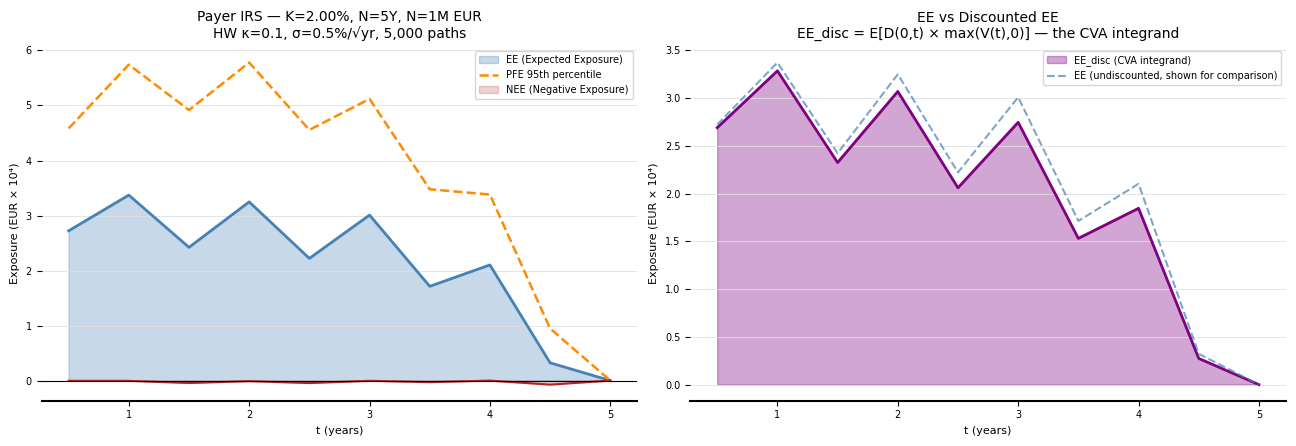

EE peaks at t=1.0Y — the typical hump shape for a payer IRS arises from
two competing effects: (1) uncertainty grows over time, (2) remaining tenor shrinks.
At inception V(0)=0 (ATM); near maturity the swap is short-dated and exposure falls.


In [6]:
# ── Plot the full exposure profile ────────────────────────────────────────────

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: EE, PFE, NEE profiles
ax = ax0
ax.fill_between(exp_dates, 0, profile['EE'] / 1e4,
                alpha=0.30, color='steelblue', label='EE (Expected Exposure)')
ax.plot(exp_dates, profile['EE']  / 1e4, '-',  color='steelblue', lw=2.0)
ax.plot(exp_dates, profile['PFE'] / 1e4, '--', color='darkorange', lw=1.8,
        label='PFE 95th percentile')
ax.fill_between(exp_dates, profile['NEE'] / 1e4, 0,
                alpha=0.20, color='firebrick', label='NEE (Negative Exposure)')
ax.plot(exp_dates, profile['NEE'] / 1e4, '-',  color='firebrick', lw=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('t (years)')
ax.set_ylabel('Exposure (EUR × 10⁴)')
direction = 'Payer' if IS_PAYER else 'Receiver'
ax.set_title(f'{direction} IRS — K={SWAP_COUPON:.2f}%, N={SWAP_MATURITY:.0f}Y, '
             f'N={SWAP_NOTIONAL/1e6:.0f}M EUR\n'
             f'HW κ={KAPPA}, σ={SIGMA}%/√yr, {sim.n_paths:,} paths')
ax.legend(fontsize=7)

# Right: Discounted EE (the CVA integrand) vs plain EE
ax = ax1
ax.fill_between(exp_dates, 0, profile['EE_disc'] / 1e4,
                alpha=0.35, color='purple', label='EE_disc (CVA integrand)')
ax.plot(exp_dates, profile['EE_disc'] / 1e4, '-', color='purple', lw=2.0)
ax.plot(exp_dates, profile['EE']      / 1e4, '--', color='steelblue', lw=1.5,
        alpha=0.7, label='EE (undiscounted, shown for comparison)')
ax.set_xlabel('t (years)')
ax.set_ylabel('Exposure (EUR × 10⁴)')
ax.set_title('EE vs Discounted EE\n'
             'EE_disc = E[D(0,t) × max(V(t),0)] — the CVA integrand')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Hump-shape insight
peak_t = exp_dates[profile['EE'].argmax()]
print(f"EE peaks at t={peak_t}Y — the typical hump shape for a payer IRS arises from")
print("two competing effects: (1) uncertainty grows over time, (2) remaining tenor shrinks.")
print("At inception V(0)=0 (ATM); near maturity the swap is short-dated and exposure falls.")


---
## 3. Default Modelling — Hazard Rate from CDS Spread

### 3.1 Reduced-Form Model

We model the counterparty's default time $\tau$ as the first jump of a Poisson process with **constant hazard rate** $h$ (flat CDS curve approximation). The risk-neutral survival probability is:

$$S(t) = \mathbb{Q}(\tau > t) = e^{-ht}$$

This is the simplest model consistent with CDS market quotes. For a full term structure of hazard rates, replace the flat $h$ with a bootstrapped piecewise-constant function $h(t)$ — the same structure but applied to each period.

### 3.2 Calibrating $h$ to a CDS Spread

A CDS with spread $S^{\text{CDS}}$ (in bps/year) priced under the flat hazard rate model:

$$S^{\text{CDS}} \approx h \times (1-R) \times 10{,}000 \quad \Rightarrow \quad h = \frac{S^{\text{CDS}}}{(1-R) \times 10{,}000}$$

(This is the standard approximation valid when $r \ll h$ and accrual effects are small.)

### 3.3 Counterparty Credit Quality Reference

| Credit rating | Typical 5Y CDS spread (EUR IG, 2026) | $h$ at $R=40\%$ |
|---|---|---|
| AAA/AA | 10–30 bps | 0.0017–0.0050/year |
| A | 30–80 bps | 0.0050–0.0133/year |
| BBB | 80–200 bps | 0.0133–0.0333/year |
| BB (HY) | 200–500 bps | 0.0333–0.0833/year |

### 3.4 Wrong-Way Risk (not modelled here)

In this notebook counterparty default is **independent of the rate environment**. In practice, a counterparty that sells IR protection may default precisely when rates spike (wrong-way risk). Modelling this requires correlating $h(t)$ with $r(t)$, which is covered in advanced CVA frameworks (Brigo & Pallavicini, 2007).


Counterparty: CDS=60 bps, R=40%
  Hazard rate h = 0.01000/year
  Survival probabilities:
    S( 1Y) = 0.9900  (1.00% cumulative default probability)
    S( 2Y) = 0.9802  (1.98% cumulative default probability)
    S( 3Y) = 0.9704  (2.96% cumulative default probability)
    S( 5Y) = 0.9512  (4.88% cumulative default probability)
    S( 7Y) = 0.9324  (6.76% cumulative default probability)
    S(10Y) = 0.9048  (9.52% cumulative default probability)


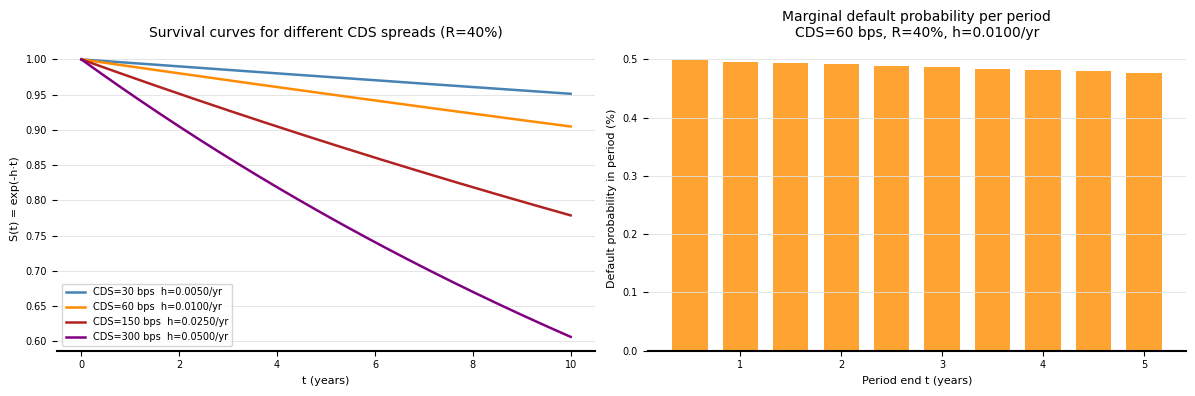

In [7]:
# ── Hazard rate and survival curve — all parameters as arguments ─────────────

def hazard_rate(cds_spread_bps: float, recovery: float) -> float:
    """
    Flat hazard rate from a CDS spread under the standard approximation.

    h = S_CDS / ((1-R) × 10000)

    Parameters
    ----------
    cds_spread_bps : CDS quoted spread in basis points/year (e.g. 80 for 80 bps)
    recovery       : recovery rate as a fraction (e.g. 0.40 for 40%)

    Returns
    -------
    float : hazard rate h in 1/year
    """
    return (cds_spread_bps / 10_000) / (1 - recovery)


def survival_prob(t: np.ndarray, h: float) -> np.ndarray:
    """
    Risk-neutral survival probability S(t) = exp(-h × t).

    Parameters
    ----------
    t : time(s) in years
    h : hazard rate from hazard_rate()

    Returns
    -------
    np.ndarray : S(t) ∈ (0, 1]
    """
    return np.exp(-h * np.asarray(t))


def default_prob_period(t1: float, t2: float, h: float) -> float:
    """
    Marginal default probability in the interval (t1, t2].

    PD(t1, t2) = S(t1) - S(t2) = exp(-h*t1) - exp(-h*t2)

    Parameters
    ----------
    t1, t2 : period boundaries in years (t2 > t1 >= 0)
    h      : hazard rate

    Returns
    -------
    float : probability of default in (t1, t2]
    """
    return float(np.exp(-h * t1) - np.exp(-h * t2))


# ── Reference counterparty: A-rated EUR corporate, CDS = 60 bps, R = 40% ─────
CDS_SPREAD_BPS  = 60.0
RECOVERY        = 0.40

h_cpty = hazard_rate(CDS_SPREAD_BPS, RECOVERY)

print(f"Counterparty: CDS={CDS_SPREAD_BPS:.0f} bps, R={RECOVERY:.0%}")
print(f"  Hazard rate h = {h_cpty:.5f}/year")
print(f"  Survival probabilities:")
for t_val in [1, 2, 3, 5, 7, 10]:
    S = survival_prob(np.array([t_val]), h_cpty)[0]
    print(f"    S({t_val:2d}Y) = {S:.4f}  ({(1-S)*100:.2f}% cumulative default probability)")

# ── Survival curve plot ───────────────────────────────────────────────────────
t_plot = np.linspace(0, 10, 200)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))

ax = ax0
for cds, color in [(30, 'steelblue'), (60, 'darkorange'), (150, 'firebrick'), (300, 'purple')]:
    h_plot = hazard_rate(cds, RECOVERY)
    ax.plot(t_plot, survival_prob(t_plot, h_plot), lw=1.8, color=color,
            label=f'CDS={cds} bps  h={h_plot:.4f}/yr')
ax.set_xlabel('t (years)')
ax.set_ylabel('S(t) = exp(-h·t)')
ax.set_title(f'Survival curves for different CDS spreads (R={RECOVERY:.0%})')
ax.legend(fontsize=7)

ax = ax1
# Marginal default probability per period (= PD(t-0.5, t) for semi-annual)
t_prev = np.concatenate([[0.0], exp_dates[:-1]])
pd_per_period = np.array([default_prob_period(t1, t2, h_cpty)
                           for t1, t2 in zip(t_prev, exp_dates)])
ax.bar(exp_dates, pd_per_period * 100, width=0.35, color='darkorange', alpha=0.8)
ax.set_xlabel('Period end t (years)')
ax.set_ylabel('Default probability in period (%)')
ax.set_title(f'Marginal default probability per period\n'
             f'CDS={CDS_SPREAD_BPS:.0f} bps, R={RECOVERY:.0%}, h={h_cpty:.4f}/yr')

plt.tight_layout()
plt.show()


---
## 4. CVA Calculation

### 4.1 Discrete CVA Formula

$$\text{CVA} = (1-R) \sum_{i=1}^{n} \underbrace{\text{EE}_{\text{disc}}(t_i)}_{\text{from MCSimulator}} \cdot \underbrace{(S(t_{i-1}) - S(t_i))}_{\text{marginal PD}}$$

Each term in the sum is the **CVA contribution** from period $[t_{i-1}, t_i]$: the expected loss given default in that period, discounted to today. The term structure of CVA contributions reveals **when** the credit risk is concentrated.

### 4.2 CS01 — Sensitivity to Credit Spread

The CS01 (credit spread delta) is the change in CVA for a +1 bps parallel shift in the CDS spread:

$$\text{CS01} \approx \text{CVA}(S^{\text{CDS}} + 1\text{ bps}) - \text{CVA}(S^{\text{CDS}})$$

For a flat hazard rate model: $\partial h / \partial S = 1/((1-R)\times10000)$, so CS01 scales approximately linearly with the exposure.

### 4.3 IRCS01 — Sensitivity to Interest Rates

The interest rate CS01 captures how CVA changes when the rate environment shifts, affecting both the EE profile (through swap MTM) and the discount factors. This is computed by re-running the exposure profile with a shifted initial rate $r_0 + 1$bps.


In [8]:
# ── CVA calculation — all parameters as arguments ────────────────────────────

def compute_cva(
    profile: dict,
    cds_spread_bps: float,
    recovery: float,
) -> dict:
    """
    CVA = (1-R) × Σ EE_disc(tᵢ) × PD(tᵢ₋₁, tᵢ)

    Parameters
    ----------
    profile        : dict from MCSimulator.exposure_profile() — must contain
                     'dates' and 'EE_disc' keys
    cds_spread_bps : counterparty CDS spread in bps/year
    recovery       : recovery rate as a fraction (0.0 – 1.0)

    Returns
    -------
    dict with:
        CVA           : scalar CVA in same units as notional
        h             : hazard rate (1/year)
        lgd           : loss given default = 1 - recovery
        survival      : survival probabilities at profile dates
        pd_period     : marginal default probability per period
        cva_by_period : CVA contribution per period (sums to CVA)
    """
    h       = hazard_rate(cds_spread_bps, recovery)
    lgd     = 1.0 - recovery
    dates   = profile['dates']

    # Marginal default probability in each period [t_{i-1}, t_i]
    t_prev    = np.concatenate([[0.0], dates[:-1]])
    pd_period = survival_prob(t_prev, h) - survival_prob(dates, h)

    # CVA by period: LGD × EE_disc(t) × PD(t-1, t)
    cva_by_period = lgd * profile['EE_disc'] * pd_period
    cva_total     = float(cva_by_period.sum())

    return {
        'CVA'           : cva_total,
        'h'             : h,
        'lgd'           : lgd,
        'survival'      : survival_prob(dates, h),
        'pd_period'     : pd_period,
        'cva_by_period' : cva_by_period,
    }


# ── Compute CVA for the reference trade ──────────────────────────────────────
result = compute_cva(profile, CDS_SPREAD_BPS, RECOVERY)

print(f"CVA Breakdown — {direction} IRS, K={SWAP_COUPON:.2f}%, {SWAP_MATURITY:.0f}Y, "
      f"N={SWAP_NOTIONAL/1e6:.0f}M EUR")
print(f"  Counterparty: CDS={CDS_SPREAD_BPS:.0f}bps, R={RECOVERY:.0%}, "
      f"h={result['h']:.5f}/yr, LGD={result['lgd']:.0%}")
print(f"")
print(f"  {'Period':>10}  {'EE_disc':>12}  {'PD(period)':>12}  {'CVA contribution':>16}")
for i, t in enumerate(exp_dates):
    print(f"  {t:>9.1f}Y  {profile['EE_disc'][i]:>12,.2f}  "
          f"{result['pd_period'][i]*100:>11.4f}%  {result['cva_by_period'][i]:>16,.2f}")
print(f"  {'':─<56}")
print(f"  {'CVA Total':>22}                           {result['CVA']:>16,.2f} EUR")
print(f"")
print(f"  CVA as % of notional: {result['CVA']/SWAP_NOTIONAL*100:.4f}%")
print(f"  CVA in bps of notional: {result['CVA']/SWAP_NOTIONAL*10000:.2f} bps")


CVA Breakdown — Payer IRS, K=2.00%, 5Y, N=1M EUR
  Counterparty: CDS=60bps, R=40%, h=0.01000/yr, LGD=60%

      Period       EE_disc    PD(period)  CVA contribution
        0.5Y     26,897.05       0.4988%             80.49
        1.0Y     32,843.66       0.4963%             97.79
        1.5Y     23,244.73       0.4938%             68.87
        2.0Y     30,686.00       0.4913%             90.46
        2.5Y     20,602.61       0.4889%             60.43
        3.0Y     27,453.14       0.4864%             80.13
        3.5Y     15,306.53       0.4840%             44.45
        4.0Y     18,454.50       0.4816%             53.33
        4.5Y      2,741.45       0.4792%              7.88
        5.0Y          0.00       0.4768%              0.00
  ────────────────────────────────────────────────────────
               CVA Total                                     583.83 EUR

  CVA as % of notional: 0.0584%
  CVA in bps of notional: 5.84 bps


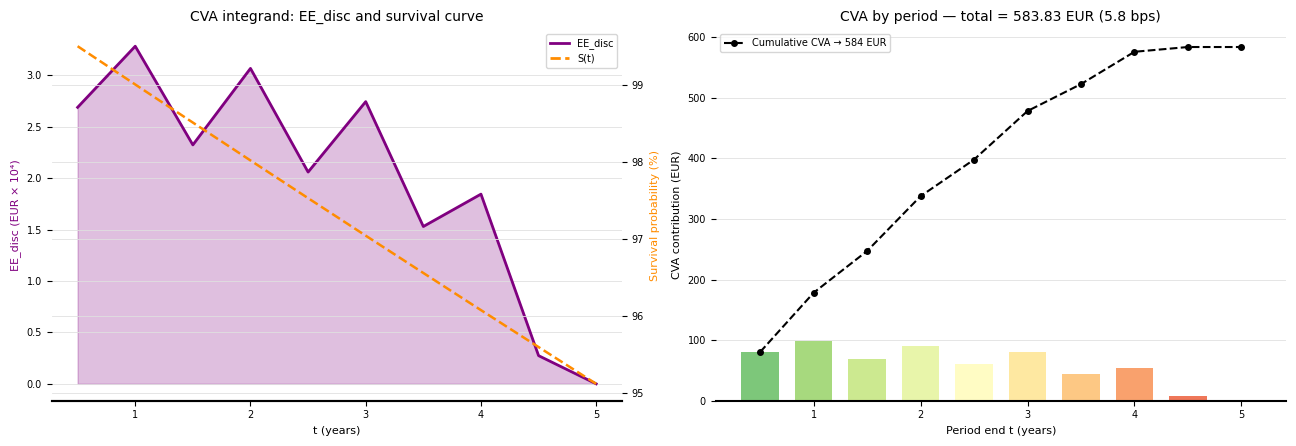

In [9]:
# ── CVA profile and contribution chart ────────────────────────────────────────

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: EE_disc, survival curve, and CVA contribution profile
ax = ax0
ax2 = ax.twinx()
ax.fill_between(exp_dates, 0, profile['EE_disc'] / 1e4,
                alpha=0.25, color='purple', label='EE_disc (left)')
ax.plot(exp_dates, profile['EE_disc'] / 1e4,  '-', color='purple', lw=2.0)
ax.set_xlabel('t (years)')
ax.set_ylabel('EE_disc (EUR × 10⁴)', color='purple')
ax2.plot(exp_dates, result['survival'] * 100, '--', color='darkorange', lw=1.8,
         label='Survival S(t) (right)')
ax2.set_ylabel('Survival probability (%)', color='darkorange')
ax.set_title('CVA integrand: EE_disc and survival curve')
lines1 = [plt.Line2D([0],[0],color='purple',lw=2), plt.Line2D([0],[0],color='darkorange',lw=2,ls='--')]
ax.legend(lines1, ['EE_disc','S(t)'], fontsize=7)

# Right: waterfall of CVA contributions by period
ax = ax1
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(exp_dates)))
bars = ax.bar(exp_dates, result['cva_by_period'], width=0.35,
              color=colors_bar, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
cva_cumsum = result['cva_by_period'].cumsum()
ax.plot(exp_dates, cva_cumsum, 'k--', lw=1.5, marker='o', ms=4,
        label=f'Cumulative CVA → {result["CVA"]:,.0f} EUR')
ax.set_xlabel('Period end t (years)')
ax.set_ylabel('CVA contribution (EUR)')
ax.set_title(f'CVA by period — total = {result["CVA"]:,.2f} EUR '
             f'({result["CVA"]/SWAP_NOTIONAL*10000:.1f} bps)')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


In [10]:
# ── CVA sensitivity analysis — vary CDS spread, recovery, direction ──────────
#
# The parametric design (all args) means we simply call compute_cva() with
# different inputs — no re-simulation needed for credit parameter changes.
# Rate vol (sigma) changes require re-running the simulator.

print("=== CVA Sensitivity Analysis ===\n")

# 1. CDS spread sensitivity (CS01 and full curve)
print("1. CVA vs CDS spread (R=40%):")
cds_grid = np.array([20, 40, 60, 80, 100, 150, 200, 300, 500])
cva_by_cds = [compute_cva(profile, cds, RECOVERY)['CVA'] for cds in cds_grid]

for cds, cva in zip(cds_grid, cva_by_cds):
    pct = cva / SWAP_NOTIONAL * 10000
    print(f"  CDS={cds:>4.0f} bps  CVA={cva:>10,.2f} EUR ({pct:.2f} bps)")

cs01 = compute_cva(profile, CDS_SPREAD_BPS+1, RECOVERY)['CVA'] - result['CVA']
print(f"  CS01 (at {CDS_SPREAD_BPS:.0f} bps): {cs01:+.2f} EUR / bps")

print("\n2. CVA vs recovery rate (CDS=60 bps):")
recovery_grid = np.array([0.0, 0.20, 0.30, 0.40, 0.50, 0.60])
for R in recovery_grid:
    cva_r = compute_cva(profile, CDS_SPREAD_BPS, R)['CVA']
    print(f"  R={R:.0%}  CVA={cva_r:>10,.2f} EUR  LGD={(1-R):.0%}")

print("\n3. CVA vs swap direction:")
for is_pay, label in [(True,'Payer (pay fixed)'), (False,'Receiver (receive fixed)')]:
    def mtm_fn_dir(paths, t):
        return irs_mtm(paths, t, payment_dates, year_fracs,
                       SWAP_COUPON, SWAP_NOTIONAL, is_pay,
                       KAPPA, SIGMA, ois, sim.dt, sim.n_steps)
    prof_dir = sim.exposure_profile(mtm_fn_dir, exp_dates)
    cva_dir  = compute_cva(prof_dir, CDS_SPREAD_BPS, RECOVERY)['CVA']
    print(f"  {label}: CVA={cva_dir:>10,.2f} EUR  "
          f"(EE peak={prof_dir['EE'].max():,.0f}, NEE min={prof_dir['NEE'].min():,.0f})")

print("\n4. CVA vs HW vol σ (fixes EE level):")
for sigma_val in [0.30, 0.50, 0.70, 1.00]:
    sim_s = MCSimulator(
        process  = HullWhiteProcess(curve=ois, kappa=KAPPA, sigma=sigma_val),
        x0=r0, T=10.0, n_steps=120, n_paths=5000, antithetic=True, seed=RNG_SEED,
    )
    def mtm_fn_s(paths, t):
        return irs_mtm(paths, t, payment_dates, year_fracs,
                       SWAP_COUPON, SWAP_NOTIONAL, IS_PAYER,
                       KAPPA, sigma_val, ois, sim_s.dt, sim_s.n_steps)
    prof_s = sim_s.exposure_profile(mtm_fn_s, exp_dates)
    cva_s  = compute_cva(prof_s, CDS_SPREAD_BPS, RECOVERY)['CVA']
    print(f"  σ={sigma_val:.2f}%/√yr  EE_peak={prof_s['EE'].max():>10,.0f} EUR  "
          f"CVA={cva_s:>10,.2f} EUR")


=== CVA Sensitivity Analysis ===

1. CVA vs CDS spread (R=40%):
  CDS=  20 bps  CVA=    197.01 EUR (1.97 bps)
  CDS=  40 bps  CVA=    391.61 EUR (3.92 bps)
  CDS=  60 bps  CVA=    583.83 EUR (5.84 bps)
  CDS=  80 bps  CVA=    773.70 EUR (7.74 bps)
  CDS= 100 bps  CVA=    961.24 EUR (9.61 bps)
  CDS= 150 bps  CVA=  1,420.13 EUR (14.20 bps)
  CDS= 200 bps  CVA=  1,865.15 EUR (18.65 bps)
  CDS= 300 bps  CVA=  2,715.26 EUR (27.15 bps)
  CDS= 500 bps  CVA=  4,267.17 EUR (42.67 bps)
  CS01 (at 60 bps): +9.55 EUR / bps

2. CVA vs recovery rate (CDS=60 bps):
  R=0%  CVA=    588.14 EUR  LGD=100%
  R=20%  CVA=    586.52 EUR  LGD=80%
  R=30%  CVA=    585.37 EUR  LGD=70%
  R=40%  CVA=    583.83 EUR  LGD=60%
  R=50%  CVA=    581.69 EUR  LGD=50%
  R=60%  CVA=    578.51 EUR  LGD=40%

3. CVA vs swap direction:
  Payer (pay fixed): CVA=    583.83 EUR  (EE peak=33,713, NEE min=-736)
  Receiver (receive fixed): CVA=      5.90 EUR  (EE peak=736, NEE min=-33,713)

4. CVA vs HW vol σ (fixes EE level):
  σ=0

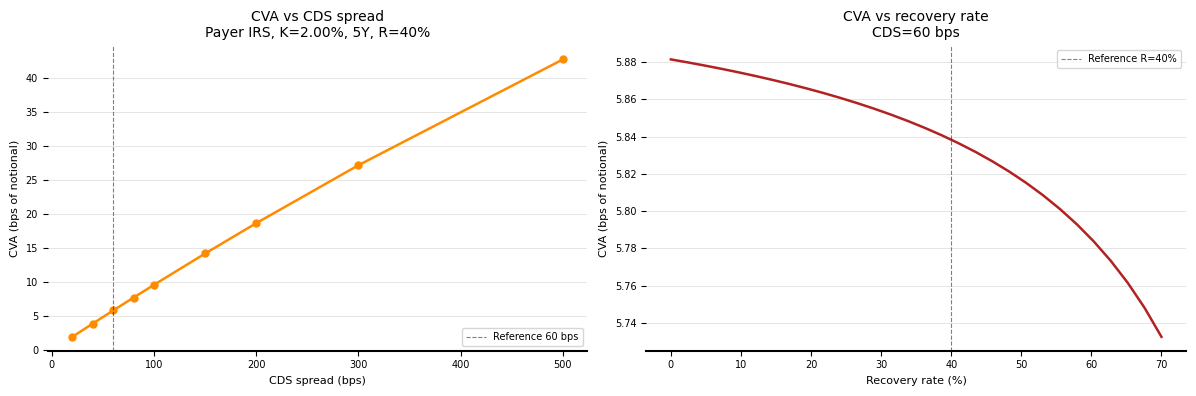

Insight: CVA is nearly linear in CDS spread (for typical credit quality) and
linear in LGD=(1-R). Higher vol (σ) increases the EE hump, raising CVA non-linearly.


In [11]:
# ── Sensitivity plots ─────────────────────────────────────────────────────────

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))

# Left: CVA vs CDS spread (log scale)
ax = ax0
ax.plot(cds_grid, [c/SWAP_NOTIONAL*10000 for c in cva_by_cds],
        'o-', color='darkorange', lw=1.8, ms=5)
ax.axvline(CDS_SPREAD_BPS, color='black', lw=0.8, ls='--', alpha=0.5,
           label=f'Reference {CDS_SPREAD_BPS:.0f} bps')
ax.set_xlabel('CDS spread (bps)')
ax.set_ylabel('CVA (bps of notional)')
ax.set_title(f'CVA vs CDS spread\n'
             f'{direction} IRS, K={SWAP_COUPON:.2f}%, {SWAP_MATURITY:.0f}Y, R={RECOVERY:.0%}')
ax.legend(fontsize=7)

# Right: CVA by recovery rate
recovery_vals = np.linspace(0.0, 0.70, 30)
cva_by_rec = [compute_cva(profile, CDS_SPREAD_BPS, R)['CVA']/SWAP_NOTIONAL*10000
              for R in recovery_vals]
ax = ax1
ax.plot(recovery_vals * 100, cva_by_rec, '-', color='firebrick', lw=1.8)
ax.axvline(RECOVERY*100, color='black', lw=0.8, ls='--', alpha=0.5,
           label=f'Reference R={RECOVERY:.0%}')
ax.set_xlabel('Recovery rate (%)')
ax.set_ylabel('CVA (bps of notional)')
ax.set_title(f'CVA vs recovery rate\nCDS={CDS_SPREAD_BPS:.0f} bps')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("Insight: CVA is nearly linear in CDS spread (for typical credit quality) and")
print("linear in LGD=(1-R). Higher vol (σ) increases the EE hump, raising CVA non-linearly.")


---
## 5. Bilateral CVA — DVA

### 5.1 DVA: The Benefit of Own Default

When we may default while the trade is **negative** to us (counterparty has receivable), counterparty bears a credit risk. From our perspective this is a **benefit** — we might not have to pay the full replacement value if we default.

$$\text{DVA} = (1-R^{\text{own}}) \sum_{i=1}^{n} \text{|NEE}_{\text{disc}}(t_i)| \cdot \text{PD}^{\text{own}}(t_{i-1}, t_i)$$

where $\text{NEE}_{\text{disc}}(t) = \mathbb{E}^{\mathbb{Q}}[D(0,t)\min(V(t),0)]$ (already in `profile['NEE']` but not yet discounted — see note below).

### 5.2 Bilateral CVA (BCVA)

$$\text{BCVA} = \text{CVA} - \text{DVA}$$

- **CVA > 0**: a cost — reduces the risk-free value of the trade
- **DVA > 0**: a benefit — but controversial. Booking DVA implies you benefit from   your own credit deterioration. IFRS 13 requires it; many risk frameworks debate it.

### 5.3 Independence Assumption

Here we assume own and counterparty default are **independent**. A full bilateral model (Brigo-Pallavicini 2007) accounts for the first-to-default correlation, which matters when both names are correlated (e.g., large bank vs sovereign).

> **Note on NEE_disc:** `MCSimulator.exposure_profile()` returns `NEE` (undiscounted) and `EE_disc` (discounted EE). For DVA we need the discounted NEE — computed below directly from the `mtm` matrix in the profile.


CVA / DVA / BCVA Summary
  Own CDS: 45 bps, R_own=40%
  Counterparty CDS: 60 bps, R=40%

  CVA  =       583.83 EUR  (5.84 bps)
  DVA  =         4.45 EUR  (0.04 bps)
  BCVA =       579.38 EUR  (5.79 bps)

  Net adjustment: risky MtM = risk-free MtM - BCVA


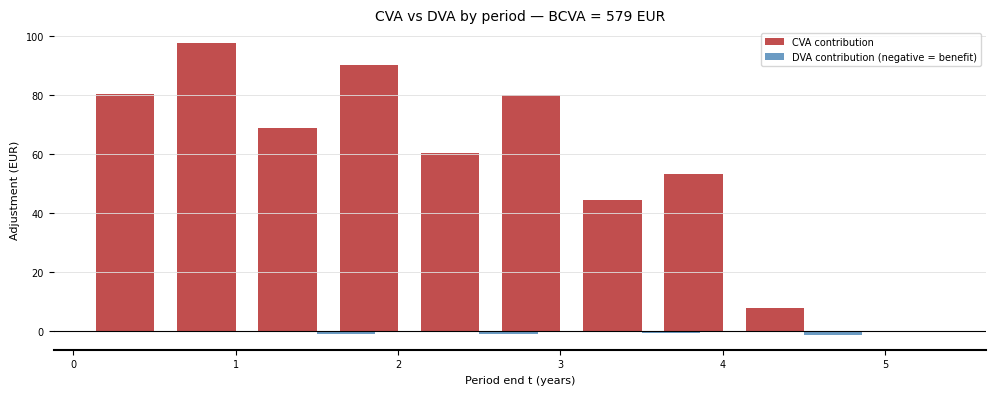

In [12]:
# ── DVA and BCVA — own default parameters as arguments ───────────────────────

def compute_dva(
    profile: dict,
    own_cds_spread_bps: float,
    own_recovery: float,
    sim: MCSimulator,
    exp_dates: np.ndarray,
) -> dict:
    """
    DVA = (1-R_own) × Σ |NEE_disc(tᵢ)| × PD_own(tᵢ₋₁, tᵢ)

    Computes discounted NEE from the raw mtm matrix in the profile,
    then applies the own-default hazard rate.

    Parameters
    ----------
    profile            : from MCSimulator.exposure_profile()
    own_cds_spread_bps : our own CDS spread (bps)
    own_recovery       : our own recovery rate
    sim                : MCSimulator — needed for sdf computation
    exp_dates          : evaluation dates

    Returns
    -------
    dict with DVA, BCVA (= CVA - DVA), and breakdown arrays.
    """
    h_own   = hazard_rate(own_cds_spread_bps, own_recovery)
    lgd_own = 1.0 - own_recovery
    dates   = profile['dates']

    # Discounted NEE: E[D(0,t) × min(V(t), 0)]
    # mtm shape: (n_paths, n_dates); sdf shape: (n_paths,)
    disc_matrix = np.column_stack([sim.sdf(t) for t in dates])   # (n_paths, n_dates)
    nee_disc    = (disc_matrix * np.minimum(profile['mtm'], 0)).mean(axis=0)

    # Default probabilities using own hazard rate
    t_prev    = np.concatenate([[0.0], dates[:-1]])
    pd_own    = survival_prob(t_prev, h_own) - survival_prob(dates, h_own)

    # DVA: LGD_own × |NEE_disc(t)| × PD_own(t)
    dva_by_period = lgd_own * np.abs(nee_disc) * pd_own
    dva_total     = float(dva_by_period.sum())

    return {
        'DVA'           : dva_total,
        'nee_disc'      : nee_disc,
        'pd_own'        : pd_own,
        'dva_by_period' : dva_by_period,
    }


# ── Reference own-credit: A-rated bank, own CDS = 45 bps, R_own = 40% ────────
OWN_CDS_BPS  = 45.0
OWN_RECOVERY = 0.40

dva_result = compute_dva(profile, OWN_CDS_BPS, OWN_RECOVERY, sim, exp_dates)
bcva       = result['CVA'] - dva_result['DVA']

print(f"CVA / DVA / BCVA Summary")
print(f"  Own CDS: {OWN_CDS_BPS:.0f} bps, R_own={OWN_RECOVERY:.0%}")
print(f"  Counterparty CDS: {CDS_SPREAD_BPS:.0f} bps, R={RECOVERY:.0%}")
print(f"")
print(f"  CVA  = {result['CVA']:>12,.2f} EUR  ({result['CVA']/SWAP_NOTIONAL*10000:.2f} bps)")
print(f"  DVA  = {dva_result['DVA']:>12,.2f} EUR  ({dva_result['DVA']/SWAP_NOTIONAL*10000:.2f} bps)")
print(f"  BCVA = {bcva:>12,.2f} EUR  ({bcva/SWAP_NOTIONAL*10000:.2f} bps)")
print(f"")
print(f"  Net adjustment: risky MtM = risk-free MtM - BCVA")

# Plot CVA vs DVA by period
fig, ax = plt.subplots(figsize=(10, 4))
w = 0.18
ax.bar(exp_dates - w, result['cva_by_period'],     width=w*2, color='firebrick',
       alpha=0.8, label='CVA contribution')
ax.bar(exp_dates + w, -dva_result['dva_by_period'], width=w*2, color='steelblue',
       alpha=0.8, label='DVA contribution (negative = benefit)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Period end t (years)')
ax.set_ylabel('Adjustment (EUR)')
ax.set_title(f'CVA vs DVA by period — BCVA = {bcva:,.0f} EUR')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


---
## 6. Regulatory CVA Capital — SA-CVA (CRR3 Art. 383)

### 6.1 What SA-CVA Measures

The **Standardised Approach to CVA** (SA-CVA, CRR3 Art. 383) computes a CVA capital charge based on **sensitivities** of the CVA portfolio to prescribed risk factors. It does not use the simulated CVA directly — instead it requires:

| Risk factor | Sensitivity | Regulatory parameter |
|---|---|---|
| Credit spread of counterparty | CS01 = $\partial\text{CVA}/\partial S^{\text{CDS}}$ | Supervisory correlation $\rho$ |
| Interest rates at each tenor | IRCS01 = $\partial\text{CVA}/\partial r(T_k)$ | Risk weight per bucket |
| FX rates (if applicable) | FX01 | Risk weight |

### 6.2 CS01 from the CVA Model

The CS01 computed here — $\partial\text{CVA}/\partial S^{\text{CDS}}$ ≈ 1 bp bump of the CDS spread — is directly usable as the SA-CVA input. Under the flat hazard rate model, $\partial h / \partial S = 1/((1-R)\times 10000)$, so:

$$\text{CS01} \approx \frac{\partial \text{CVA}}{\partial S} = (1-R) \sum_{i} \text{EE}_{\text{disc}}(t_i) \cdot \frac{\partial \text{PD}_i}{\partial h} \cdot \frac{1}{(1-R)\times 10000}$$

### 6.3 From CVA Model to CVA Capital

SA-CVA capital $K_{\text{CVA}}$ is computed from an aggregation of risk buckets:

$$K_{\text{CVA}} = \lambda \cdot \sqrt{\text{(delta bucket charges)}^2 + \text{(vega bucket charges)}^2}$$

where $\lambda$ is a scalar multiplier (currently 1.0) and delta charges are CS01 × risk weight × counterparty sensitivity. Full details in CRR3 Art. 383 and the Basel CVA framework (December 2017).

> **For production implementation:** the SA-CVA engine in QRE-57 (XVA OOP class) will wrap the sensitivity computation over a netting set using the `MCSimulator.exposure_profile()` infrastructure built here.


---
## Summary

| Step | Formula | Function |
|---|---|---|
| **IRS MTM** | $V_{\text{payer}}(t) = N[(1-P^{HW}(t,T_n)) - K/100\cdot\sum\delta_i P^{HW}(t,T_i)]$ | `irs_mtm(paths, t, payment_dates, year_fracs, K, N, is_payer, κ, σ, curve, dt, n_steps)` |
| **EE profile** | $\text{EE}_{\text{disc}}(t) = \mathbb{E}[D(0,t)\max(V(t),0)]$ | `MCSimulator.exposure_profile(mtm_fn, dates)` |
| **Hazard rate** | $h = S^{\text{CDS}}/(10000(1-R))$ | `hazard_rate(cds_spread_bps, recovery)` |
| **Survival** | $S(t) = e^{-ht}$ | `survival_prob(t, h)` |
| **Default prob** | $\text{PD}(t_1,t_2) = e^{-ht_1} - e^{-ht_2}$ | `default_prob_period(t1, t2, h)` |
| **CVA** | $(1-R)\sum_i \text{EE}_{\text{disc}}(t_i)\cdot\text{PD}(t_{i-1},t_i)$ | `compute_cva(profile, cds_bps, recovery)` |
| **DVA** | $(1-R^{\text{own}})\sum_i |\text{NEE}_{\text{disc}}(t_i)|\cdot\text{PD}^{\text{own}}_i$ | `compute_dva(profile, own_cds_bps, own_recovery, sim, dates)` |
| **BCVA** | $\text{CVA} - \text{DVA}$ | from above |

**Design principle:** every function takes its full parameter set as explicit arguments. Changing the instrument, counterparty, rate model, or recovery assumption is a single argument substitution — no global state, no re-simulation required unless σ or κ changes.

**Next:** [QRE-54 — FVA](09_fva.ipynb) — funding valuation adjustment. Uses `NEE_disc` (negative exposure) to compute the cost of posting collateral when the trade is out-of-the-money; extends to CSA impact and OIS vs SOFR funding.
